In [1]:
# ============================================================================
# Loading required libraries
# ============================================================================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14
from scipy import integrate
from lmfit import Parameters
from pyazr import azure2
from SRIM import SRIM
from scipy.special import erf
import time

warnings.filterwarnings('ignore')

In [2]:
# ============================================================================
# Building the logic of the model
# ============================================================================

# Boltzmann constant in keV/K
k = 8.617e-5

# Doppler effect
dopp = np.sqrt(2 * 1.007 / 19 * 0.250 * k * (80 + 273))

print('Doppler effect =', dopp)

# Read the element stopping data
H_in_F = SRIM("stopping/H_in_F.stop")
H_in_H = SRIM("stopping/H_in_H.stop")
H_in_Fe = SRIM("stopping/H_in_Fe.stop")
H_in_Ta = SRIM("stopping/H_in_Ta.stop")
H_in_Ca = SRIM("stopping/H_in_Ca.stop")
H_in_O = SRIM("stopping/H_in_O.stop")

# Get the effective stopping power for F implanted in Fe
def effective_stopping_Fe(energy, n_inactive=1, n_active=3):
    stoichiometry = n_inactive / n_active
    return H_in_F.eval(energy) + stoichiometry * H_in_Fe.eval(energy)

# Get the effective stopping power for F implanted in Ta
def effective_stopping_Ta(energy, n_inactive=1, n_active=5):
    stoichiometry = n_inactive / n_active
    return H_in_F.eval(energy) + stoichiometry * H_in_Ta.eval(energy)

# Straggling
popt = [0.75324712]
def straggling(x):
    return popt[0] * np.sqrt(x)

def gaussian(x, x0, s):
    return np.exp(-(x - x0)**2 / (s*s*2))

# Profile for SUDF#3 (single step - square)
def profile_sudf3(de, theta):
    if de > 0 and de < theta["width"]:
        return 1
    else:
        return 0

# Profile for SUDF#4 (multi-step)
def profile_sudf4(de, theta):
    if de > 0 and de < theta["width"]:
        return 1
    elif de > theta["width"] and de < theta["width2"] + theta["width"]:
        return theta["norm1"]
    elif de > theta["width2"] + theta["width"] and de < theta["width2"] + theta["width"] + theta["width3"]:
        return theta["norm2"]
    else:
        return 0

# Profile for Gaussian (IMP_LTA#2 and IMP_LFE#2)
def profile_gaussian(de, theta):
    if de <= 0:
        return 0
    else:
        return gaussian(de, theta["mean"], theta["std"])

def cross_section(x0, energies, extrap):
    cross = np.interp(x0, energies * 1e3, extrap)
    return cross

def reaction_yield_Ta(x0, theta, de, energies, extrap, profile_func):
    cross = cross_section(x0, energies, extrap) * 1e-24
    stop = effective_stopping_Ta(x0, theta["n_ta"], theta["n_f"]) * 1e-15 * 1e-3
    p = profile_func(de, theta)
    return cross / stop * p

def reaction_yield_Fe(x0, theta, de, energies, extrap, profile_func):
    cross = cross_section(x0, energies, extrap) * 1e-24
    stop = effective_stopping_Fe(x0, theta["n_fe"], theta["n_f"]) * 1e-15 * 1e-3
    p = profile_func(de, theta)
    return cross / stop * p

def integrand(x, theta, x0, energies, extrap, profile_func, reaction_yield_func):
    de = x0 - x
    
    # Get beam width
    s = np.sqrt(pow(theta["beam"], 2) + pow(dopp, 2))
    s = np.sqrt(pow(theta["strag"] * straggling(de), 2) + pow(s, 2)) if de > 0 else s

    # Convolve the gaussian with the straggling
    array = np.linspace(x - 3 * s, x + 3 * s, 100)
    gauss = gaussian(array, x, s)

    # Normalize the gaussian
    step = array[1] - array[0]
    norm = np.sum(gauss) * step
    
    # Convolve
    conv = np.sum(gauss * reaction_yield_func(array, theta, de, energies, extrap, profile_func)) * step / norm

    return conv

def straggled_profile(x, theta, energies, extrap, profile_func, reaction_yield_func, xmin_offset=-100):
    y = np.zeros(shape=len(x))
    for idx in range(len(x)):
        nsteps = 500
        xmin, xmax = x[idx] + xmin_offset, x[idx]
        dx = np.abs(xmax - xmin) / nsteps
        y[idx] = integrate.simpson([integrand(x_i, theta, x[idx], energies, extrap, profile_func, reaction_yield_func) 
                                     for x_i in np.linspace(xmin, xmax, nsteps)], dx=dx)
    return y

def model(x, theta, energies, extrap, profile_func, reaction_yield_func, xmin_offset=-100):
    sign = straggled_profile(x, theta, energies, extrap, profile_func, reaction_yield_func, xmin_offset)
    back = 0
    return sign + back

def compute_target(target_name, scan_num, params, grid_range, energies, extrap, 
                   profile_func, reaction_yield_func, xmin_offset=-100):
    """
    Compute the model for a given target
    """
    start_time = time.time()
    print(f"\nComputing {target_name} - Scan {scan_num}...")
    
    # Read the CSV file of yield for the target
    df = pd.read_csv(f"/data0/biasissi/LUNA/19F+p_g+20Ne/Yield_scans/Results/Yield_{target_name}.csv")
    df = df[df["Scan"] == f"Scan {scan_num}"]
    
    # Recover the scan data
    x, y, y_err = df["Energy"], df["Yield"], df["Yield Error"]
    
    # Refine the yield data
    mask = (~np.isnan(x)) & (x < 300)
    x = x[mask].to_numpy()
    y = y[mask].to_numpy()
    y_err = y_err[mask].to_numpy()

    mask = (x > 240) & (x < 250)
    bias = np.mean(y[mask]) * 0.1
    y_err += bias
    
    eff = 0.689
    q_e = 1.602176634e-19
    
    # Convert to CM
    x = x * 19 / 20.007
    
    # Calculate model
    grid = np.linspace(grid_range[0], grid_range[1], 150)
    y_mod = model(grid, params, energies, extrap, profile_func, reaction_yield_func, xmin_offset)
    
    # Calculate profile for plotting
    grid_profile = np.linspace(-10, 100, 1000)
    p = np.array([profile_func(de, params) for de in grid_profile])
    grid_profile += 214.8
    
    elapsed = time.time() - start_time
    print(f"  Completed in {elapsed:.2f} seconds")
    
    return {
        'x': x, 'y': y, 'y_err': y_err, 'scan_ID': scan_num,
        'x_mod': grid, 'y_mod': y_mod / q_e / 1e6 * eff,
        'grid_profile': grid_profile, 'profile': p,
        'params': params
    }

Doppler effect = 0.02839149987232094



Loading cross-section data...
  Loaded 55001 data points


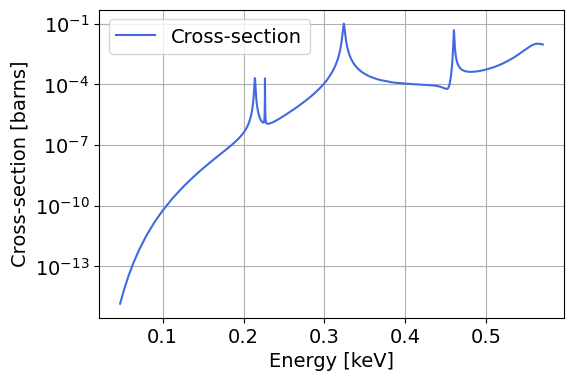

In [3]:
# Read the common cross-section file
print("\nLoading cross-section data...")
# data = np.loadtxt("utils/19F_pag_50-450keV.extrap", usecols=(0, 3))
data = np.loadtxt("utils/all_imp.extrap", usecols=(0, 3))
energies, extrap = data[:, 0], data[:, 1]
print(f"  Loaded {len(energies)} data points")

# Plot the cross-section
plt.figure(figsize=(6,4))
plt.yscale('log')
plt.plot(energies, extrap, label='Cross-section', color='royalblue')
plt.xlabel('Energy [keV]')
plt.ylabel('Cross-section [barns]')
plt.legend()
plt.grid()
plt.show()

In [4]:
# ============================================================================
# Computing all targets
# ============================================================================

# SUDF#3 - Scan 5 (Single step, Ta)
params_sudf3 = Parameters()
params_sudf3.add('beam', value=0.12, vary=False)
params_sudf3.add('n_ta', value=3.15, vary=True)
params_sudf3.add('n_f', value=1, vary=True)
params_sudf3.add('strag', value=1, vary=False)
sudf3_range = (200, 300)

eff_stop_225 = effective_stopping_Ta(214.2419, params_sudf3["n_ta"], params_sudf3["n_f"])
eff_stop_340 = effective_stopping_Ta(324.4419, params_sudf3["n_ta"], params_sudf3["n_f"])
correction = eff_stop_225 / eff_stop_340

params_sudf3.add('width', value=72*correction, vary=True)

result_sudf3 = compute_target('SUDF#3', 5, params_sudf3, sudf3_range, energies, extrap, 
                               profile_sudf3, reaction_yield_Ta, -100)

# IMP_LTA#2 - Scan 2 (Gaussian, Ta)
params_lta = Parameters()
params_lta.add('beam', value=0.12, vary=False)
params_lta.add('n_ta', value=2.80, vary=True)
params_lta.add('n_f', value=1, vary=True)
params_lta.add('strag', value=1, vary=False)
lta_range = (200, 250)

eff_stop_225 = effective_stopping_Ta(214.2419, params_lta["n_ta"], params_lta["n_f"])
eff_stop_340 = effective_stopping_Ta(324.4419, params_lta["n_ta"], params_lta["n_f"])
correction = eff_stop_225 / eff_stop_340

params_lta.add('width', value=10, vary=True)
params_lta.add('mean', value=6.6*correction, vary=True)
params_lta.add('std', value=4.4*correction, vary=True)

result_lta = compute_target('IMP_LTA#2', 2, params_lta, lta_range, energies, extrap, 
                            profile_gaussian, reaction_yield_Ta, -50)

# IMP_LFE#2 - Scan 1 (Gaussian, Fe)
params_lfe = Parameters()
params_lfe.add('beam', value=0.12, vary=False)
params_lfe.add('n_fe', value=1.60, vary=True)
params_lfe.add('n_f', value=1, vary=True)
params_lfe.add('strag', value=1, vary=False)
lfe_range = (205, 250)

eff_stop_225 = effective_stopping_Fe(214.2419, params_lfe["n_fe"], params_lfe["n_f"])
eff_stop_340 = effective_stopping_Fe(324.4419, params_lfe["n_fe"], params_lfe["n_f"])
correction = eff_stop_225 / eff_stop_340

params_lfe.add('width', value=10, vary=True)
params_lfe.add('mean', value=5.3*correction, vary=True)
params_lfe.add('std', value=4.6*correction, vary=True)

result_lfe = compute_target('IMP_LFE#2', 1, params_lfe, lfe_range, energies, extrap, 
                            profile_gaussian, reaction_yield_Fe, -50)

# SUDF#4 - Scan 4 (Multi-step, Ta)
params_sudf4 = Parameters()
params_sudf4.add('beam', value=0.12, vary=False)
params_sudf4.add('n_ta', value=2.225, vary=True)
params_sudf4.add('n_f', value=1, vary=True)
params_sudf4.add('strag', value=1, vary=False)
sudf4_range = (205, 260)

eff_stop_225 = effective_stopping_Ta(213.9419, params_sudf4["n_ta"], params_sudf4["n_f"])
eff_stop_340 = effective_stopping_Ta(324.4419, params_sudf4["n_ta"], params_sudf4["n_f"])
correction = eff_stop_225 / eff_stop_340

params_sudf4.add('width', value=8.25*correction, vary=True)
params_sudf4.add('width2', value=10*correction, vary=True)
params_sudf4.add('width3', value=20*correction, vary=True)
params_sudf4.add('norm1', value=0.34*correction, vary=True)
params_sudf4.add('norm2', value=0.11*correction, vary=True)

result_sudf4 = compute_target('SUDF#4', 4, params_sudf4, sudf4_range, energies, extrap, 
                               profile_sudf4, reaction_yield_Ta, -100)


Computing SUDF#3 - Scan 5...
  Completed in 6.79 seconds

Computing IMP_LTA#2 - Scan 2...
  Completed in 6.83 seconds

Computing IMP_LFE#2 - Scan 1...
  Completed in 6.72 seconds

Computing SUDF#4 - Scan 4...
  Completed in 7.42 seconds



Creating figure...


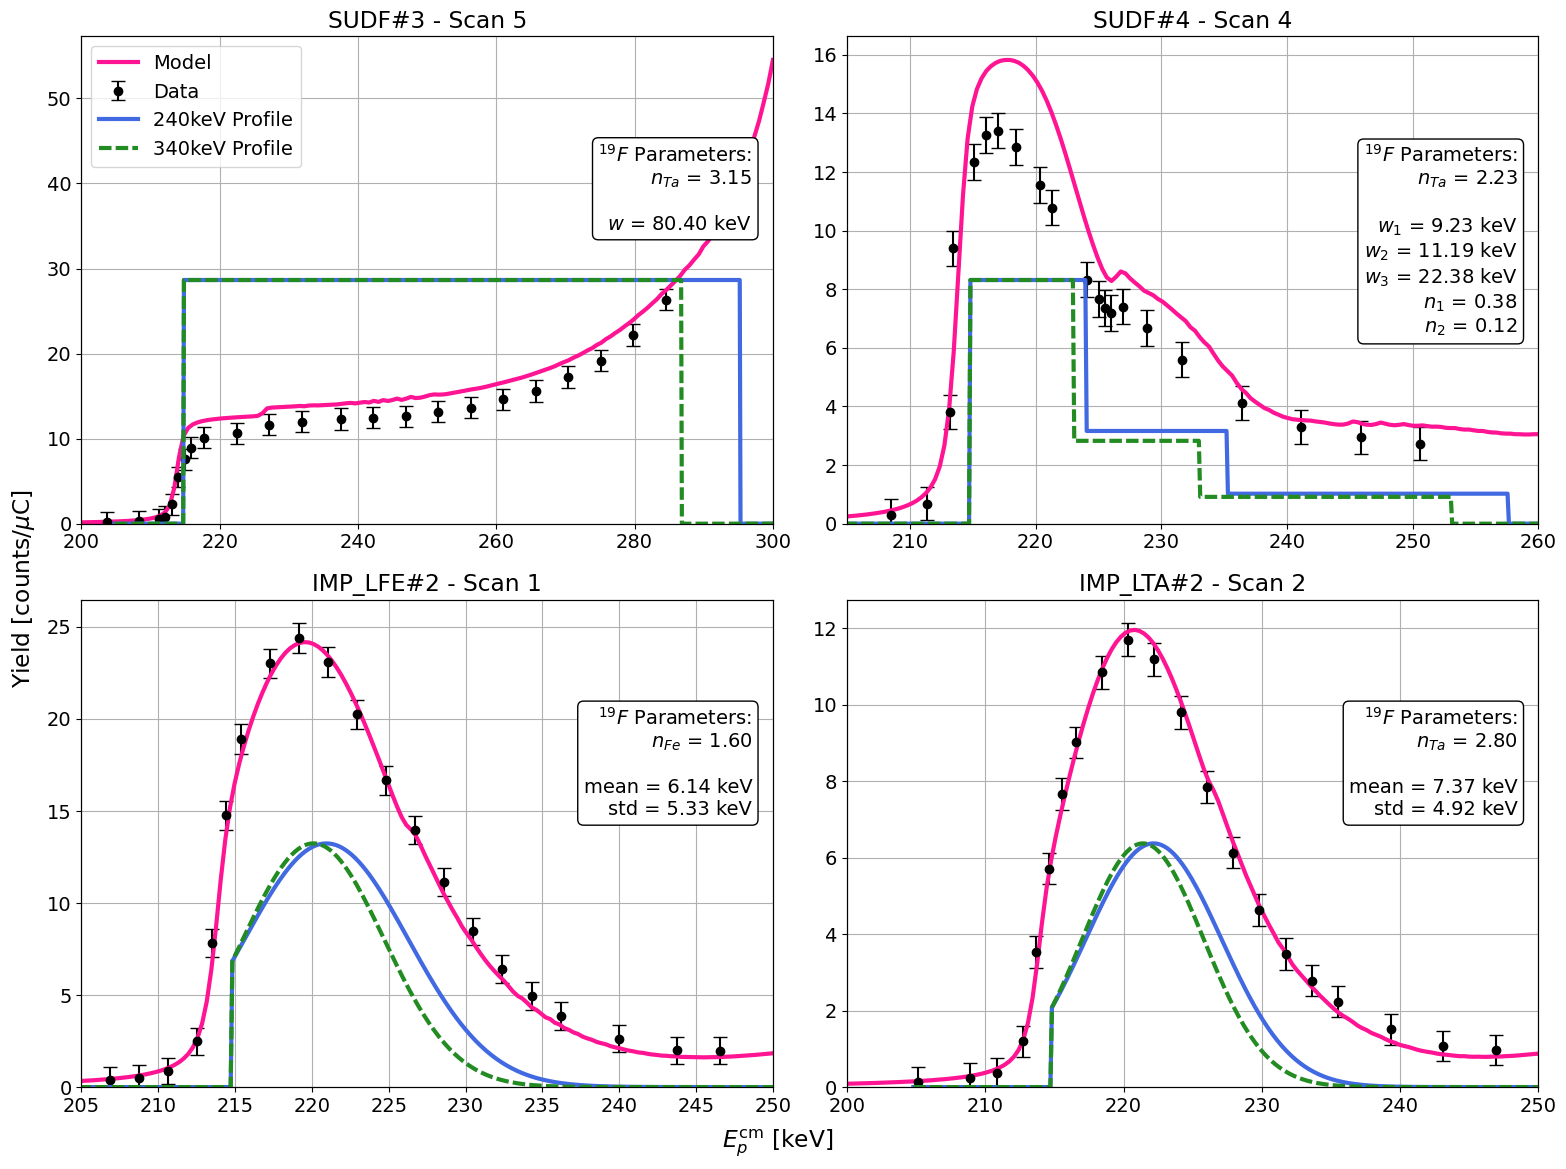


All computations completed!


In [5]:
# ============================================================================
# Create the 4-subplot figure
# ============================================================================

def format_params_text(params, profile_type):
    """
    Format parameter text for display in subplot
    """
    lines = [r'${}^{19}F$ Parameters:']
    
    # Stoichiometry
    if 'n_ta' in params:
        lines.append(f"$n_{{Ta}}$ = {params['n_ta'].value:.2f}")
    if 'n_fe' in params:
        lines.append(f"$n_{{Fe}}$ = {params['n_fe'].value:.2f}")
    # lines.append(f"$n_F$ = {params['n_f'].value:.2f}")
    
    # Profile parameters
    lines.append("")  # Empty line for spacing
    if profile_type == 'single_step':
        lines.append(f"$w$ = {params['width'].value:.2f} keV")
    elif profile_type == 'multi_step':
        lines.append(f"$w_1$ = {params['width'].value:.2f} keV")
        lines.append(f"$w_2$ = {params['width2'].value:.2f} keV")
        lines.append(f"$w_3$ = {params['width3'].value:.2f} keV")
        lines.append(f"$n_1$ = {params['norm1'].value:.2f}")
        lines.append(f"$n_2$ = {params['norm2'].value:.2f}")
    elif profile_type == 'gaussian':
        lines.append(f"mean = {params['mean'].value:.2f} keV")
        lines.append(f"std = {params['std'].value:.2f} keV")
    
    return '\n'.join(lines)

print("\nCreating figure...")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Define initial parameters (before correction)
initial_params = [
    (72, 'single_step'),
    ({'width': 8.25, 'width2': 10, 'width3': 20, 'norm1': 0.34, 'norm2': 0.11}, 'multi_step'),
    ({'mean': 5.3, 'std': 4.6}, 'gaussian'),
    ({'mean': 6.6, 'std': 4.4}, 'gaussian')
]

results = [
    (result_sudf3, f"SUDF#3 - Scan {result_sudf3['scan_ID']}", sudf3_range, (0, None), 'single_step'),
    (result_sudf4, f"SUDF#4 - Scan {result_sudf4['scan_ID']}", sudf4_range, (0, None), 'multi_step'),
    (result_lfe, f"IMP_LFE#2 - Scan {result_lfe['scan_ID']}", lfe_range, (0, None), 'gaussian'),
    (result_lta, f"IMP_LTA#2 - Scan {result_lta['scan_ID']}", lta_range, (0, None), 'gaussian')
]

for idx, (result, title, xlim, ylim, profile_type) in enumerate(results):
    ax = axes[idx]
    
    # Plot data and model
    ax.errorbar(result['x'], result['y'], yerr=result['y_err'], 
                fmt='o', label='Data', color='black', capsize=5)
    ax.plot(result['x_mod'], result['y_mod'], lw=3, 
            color='deeppink', label='Model')
    
    # use per-axis labels (Axes has set_xlabel/set_ylabel)
    fig.supylabel(r'Yield [counts/$\mu$C]', x=0.02)
    fig.supxlabel(r'$E_p^\text{cm}$ [keV]' , y=0.025)
    ax.set_title(title)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    
    # Add profile on secondary y-axis
    ax2 = ax.twinx()
    ax2.plot(result['grid_profile'], result['profile'], 
             ls='solid', lw=3, label='240keV Profile', color='royalblue')
    
    # Calculate and plot initial profile (without correction)
    grid_profile = np.linspace(-10, 100, 1000)
    initial = initial_params[idx][0]
    
    if profile_type == 'single_step':
        p_initial = np.array([1 if 0 < de < initial else 0 for de in grid_profile])
    elif profile_type == 'gaussian':
        p_initial = np.array([gaussian(de, initial['mean'], initial['std']) if de > 0 else 0 for de in grid_profile])
    elif profile_type == 'multi_step':
        def multi_step_func(de, params):
            if de > 0 and de < params['width']:
                return 1
            elif de > params['width'] and de < params['width2'] + params['width']:
                return params['norm1']
            elif de > params['width2'] + params['width'] and de < params['width2'] + params['width'] + params['width3']:
                return params['norm2']
            else:
                return 0
        p_initial = np.array([multi_step_func(de, initial) for de in grid_profile])
    
    grid_profile_shifted = grid_profile + 214.8
    ax2.plot(grid_profile_shifted, p_initial, lw=3, label='340keV Profile', color='forestgreen', ls=(0,(3,1)))
    
    ax2.set_yticks([])
    ax2.set_ylabel('')
    ax2.set_ylim(0, 2)
    
    # Combine legends
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    if ax == axes[0]:
        ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    ax.grid(True)

    # Add parameter text box
    param_text = format_params_text(result['params'], profile_type)
    ax.text(0.97, 0.78, param_text, 
            transform=ax.transAxes,
            fontsize=14,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white'))

plt.tight_layout()
plt.savefig("results/all_targets_240.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nAll computations completed!")